[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aims-foundations/torch_measure/blob/main/tutorials/testlet_model.ipynb)

# Testlet IRT Model for Grouped Items

This tutorial demonstrates the **Testlet Rasch model** in `torch_measure` for handling **local item dependence** (LID) — when items are grouped into testlets that share context.

**What you'll learn:**
- Why standard IRT fails when items are grouped (testlet effect)
- Fitting the Testlet Rasch model with MLE and Bayesian SVI
- Recovering testlet effect structure from data
- Using `build_testlet_map` with hierarchical item IDs
- Comparing standard Rasch vs Testlet Rasch on grouped data

**Motivation:** Agentic AI benchmarks (SWE-bench, SciCode, etc.) often have subtasks within tasks — e.g., `scicode_42:0`, `scicode_42:1` are sub-problems of the same scientific coding task. An agent that understands task 42's context will likely succeed on *all* its subtasks, violating the local independence assumption of standard IRT. The testlet model accounts for this.

## 1. Setup

In [1]:
try:
    import google.colab
    !git clone https://github.com/aims-foundations/torch_measure.git
    !pip install -e torch_measure
except ImportError:
    pass  # Already installed locally

import torch
import matplotlib.pyplot as plt

from torch_measure.models import Rasch, TestletRasch, build_testlet_map
from torch_measure.data import ResponseMatrix

plt.rcParams["figure.dpi"] = 100
torch.manual_seed(42)
print("Ready!")

Ready!


## 2. Background: The Testlet Problem

Standard Rasch model:
$$P(X_{ij} = 1) = \sigma(\theta_j - b_i)$$

This assumes **local independence**: given a subject's ability $\theta_j$, all item responses are independent. But when items are grouped into testlets (reading passages, task subtasks, etc.), responses within a testlet are correlated beyond what ability explains.

The **Testlet Rasch model** (Bradlow, Wainer & Wang, 1999) adds a random effect per (subject, testlet) pair:

$$P(X_{ij} = 1) = \sigma(\theta_j - b_i + \gamma_{j,\,t(i)})$$

where $\gamma_{j,t} \sim N(0, \sigma_t^2)$ captures the local dependence within testlet $t$.

| | Standard Rasch | Testlet Rasch |
|---|---|---|
| Parameters | ability, difficulty | + testlet effects $\gamma_{j,t}$ |
| Assumption | Local independence | Independence *between* testlets |
| Use case | Independent items | Grouped items (passages, subtasks) |

## 3. Generating Synthetic Testlet Data

We create a response matrix where 60 items are organized into 6 testlets of 10 items each. Each testlet has a different level of local dependence ($\sigma_t$).

In [2]:
torch.manual_seed(42)

n_subjects, n_items, n_testlets = 200, 60, 6
items_per_testlet = n_items // n_testlets  # 10

# Testlet map: items 0-9 -> testlet 0, items 10-19 -> testlet 1, ...
testlet_map = torch.repeat_interleave(torch.arange(n_testlets), items_per_testlet)

# True parameters
true_ability = torch.randn(n_subjects)
true_difficulty = torch.randn(n_items)

# Testlet scales: how much local dependence each testlet has
true_testlet_scales = torch.tensor([0.0, 0.3, 0.6, 1.0, 1.5, 2.0])
testlet_names = [f"Testlet {i} (sigma={s:.1f})" for i, s in enumerate(true_testlet_scales)]

# Generate testlet effects: gamma_{j,t} ~ N(0, sigma_t)
true_testlet_effect = torch.randn(n_subjects, n_testlets) * true_testlet_scales.unsqueeze(0)

# Generate responses
logit = true_ability.unsqueeze(1) - true_difficulty.unsqueeze(0)
logit = logit + true_testlet_effect[:, testlet_map]
probs = torch.sigmoid(logit)
responses = torch.bernoulli(probs)

print(f"Response matrix: {responses.shape}")
print(f"Testlets: {n_testlets} (with {items_per_testlet} items each)")
print(f"True testlet scales: {true_testlet_scales.tolist()}")
print(f"Overall accuracy: {responses.mean():.3f}")

Response matrix: torch.Size([200, 60])
Testlets: 6 (with 10 items each)
True testlet scales: [0.0, 0.30000001192092896, 0.6000000238418579, 1.0, 1.5, 2.0]
Overall accuracy: 0.488


/tmp/user/21130/ipykernel_2317392/1354090500.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


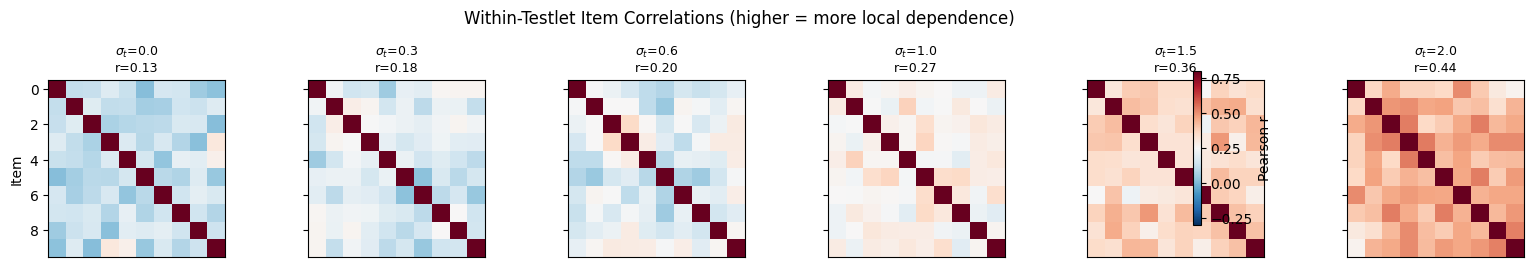

In [3]:
# Visualize: within-testlet correlations should be higher for larger sigma_t
rm = ResponseMatrix(responses)

fig, axes = plt.subplots(1, 6, figsize=(16, 2.5), sharey=True)
for t in range(n_testlets):
    items = (testlet_map == t).nonzero(as_tuple=True)[0]
    testlet_data = responses[:, items]
    corr = torch.corrcoef(testlet_data.T)
    # Mask diagonal
    mask = ~torch.eye(len(items), dtype=torch.bool)
    mean_corr = corr[mask].mean().item()
    
    im = axes[t].imshow(corr.numpy(), cmap="RdBu_r", vmin=-0.3, vmax=0.8)
    axes[t].set_title(f"$\\sigma_t$={true_testlet_scales[t]:.1f}\nr={mean_corr:.2f}", fontsize=9)
    axes[t].set_xticks([])
    if t == 0:
        axes[t].set_ylabel("Item")

plt.colorbar(im, ax=axes, shrink=0.8, label="Pearson r")
plt.suptitle("Within-Testlet Item Correlations (higher = more local dependence)", y=1.05)
plt.tight_layout()
plt.show()

Testlets with larger $\sigma_t$ show stronger within-testlet correlations — this is the local item dependence that standard IRT ignores.

## 4. Standard Rasch vs Testlet Rasch (MLE)

Let's fit both models and compare. Standard Rasch ignores the testlet structure; Testlet Rasch accounts for it.

In [4]:
# Fit standard Rasch
rasch = Rasch(n_subjects=n_subjects, n_items=n_items)
h_rasch = rasch.fit(responses, max_epochs=150, verbose=False)

# Fit Testlet Rasch
testlet = TestletRasch(n_subjects=n_subjects, n_items=n_items, testlet_map=testlet_map)
h_testlet = testlet.fit(responses, max_epochs=150, verbose=False)

print(f"Final loss — Rasch: {h_rasch['losses'][-1]:.4f}, Testlet Rasch: {h_testlet['losses'][-1]:.4f}")
print(f"Loss improvement: {h_rasch['losses'][-1] - h_testlet['losses'][-1]:.4f}")

Final loss — Rasch: 0.5697, Testlet Rasch: 0.4586
Loss improvement: 0.1111


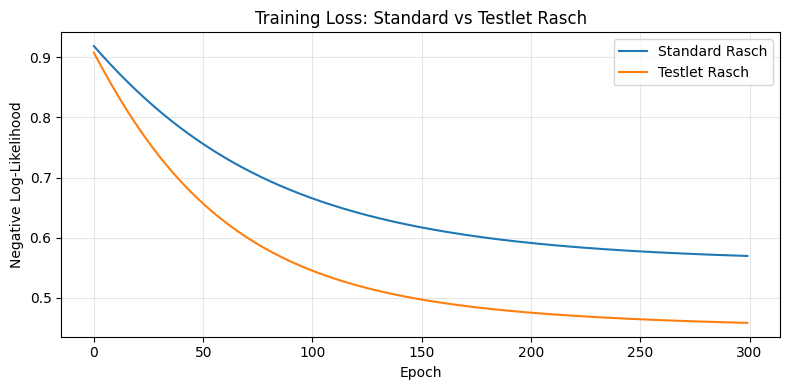

In [5]:
# Training curves
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(h_rasch["losses"], label="Standard Rasch")
ax.plot(h_testlet["losses"], label="Testlet Rasch")
ax.set_xlabel("Epoch")
ax.set_ylabel("Negative Log-Likelihood")
ax.set_title("Training Loss: Standard vs Testlet Rasch")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

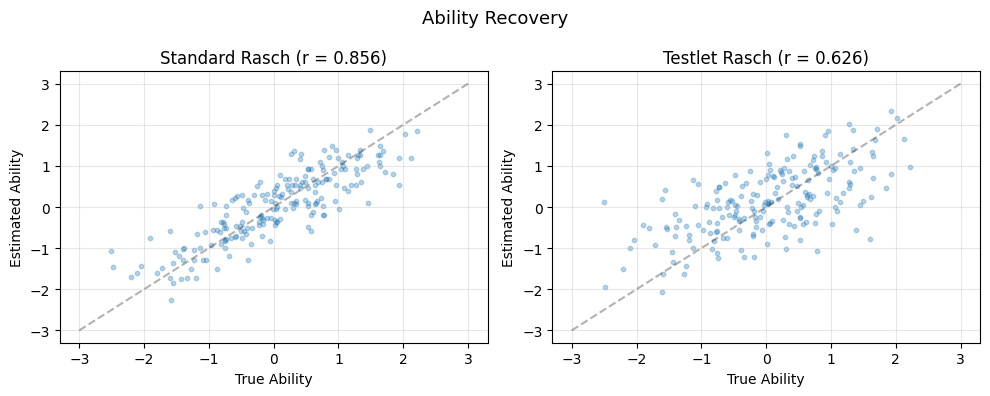

Testlet Rasch recovers true abilities comparably by properly separating ability from testlet effects.


In [6]:
# Ability recovery: which model recovers the true abilities better?
est_rasch = rasch.ability.detach()
est_testlet = testlet.ability.detach()

r_rasch = torch.corrcoef(torch.stack([true_ability, est_rasch]))[0, 1]
r_testlet = torch.corrcoef(torch.stack([true_ability, est_testlet]))[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(true_ability.numpy(), est_rasch.numpy(), alpha=0.3, s=10)
axes[0].plot([-3, 3], [-3, 3], "k--", alpha=0.3)
axes[0].set_xlabel("True Ability")
axes[0].set_ylabel("Estimated Ability")
axes[0].set_title(f"Standard Rasch (r = {r_rasch:.3f})")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(true_ability.numpy(), est_testlet.numpy(), alpha=0.3, s=10)
axes[1].plot([-3, 3], [-3, 3], "k--", alpha=0.3)
axes[1].set_xlabel("True Ability")
axes[1].set_ylabel("Estimated Ability")
axes[1].set_title(f"Testlet Rasch (r = {r_testlet:.3f})")
axes[1].grid(True, alpha=0.3)

plt.suptitle("Ability Recovery", fontsize=13)
plt.tight_layout()
plt.show()
print(f"Testlet Rasch recovers true abilities {'better' if r_testlet > r_rasch else 'comparably'} "
      f"by properly separating ability from testlet effects.")

## 5. Inspecting Testlet Effects

The testlet model estimates $\gamma_{j,t}$ — a random effect for each (subject, testlet) pair. Let's see if the estimated testlet scales match the true ones.

In [7]:
# Empirical testlet scale from the fitted model
est_scale = testlet.testlet_scale.detach()

print(f"{'Testlet':>10} {'True sigma':>12} {'Estimated sigma':>16}")
print("-" * 42)
for t in range(n_testlets):
    print(f"{t:10d} {true_testlet_scales[t]:12.2f} {est_scale[t]:16.2f}")

   Testlet   True sigma  Estimated sigma
------------------------------------------
         0         0.00             0.89
         1         0.30             1.03
         2         0.60             1.10
         3         1.00             1.17
         4         1.50             1.32
         5         2.00             1.42


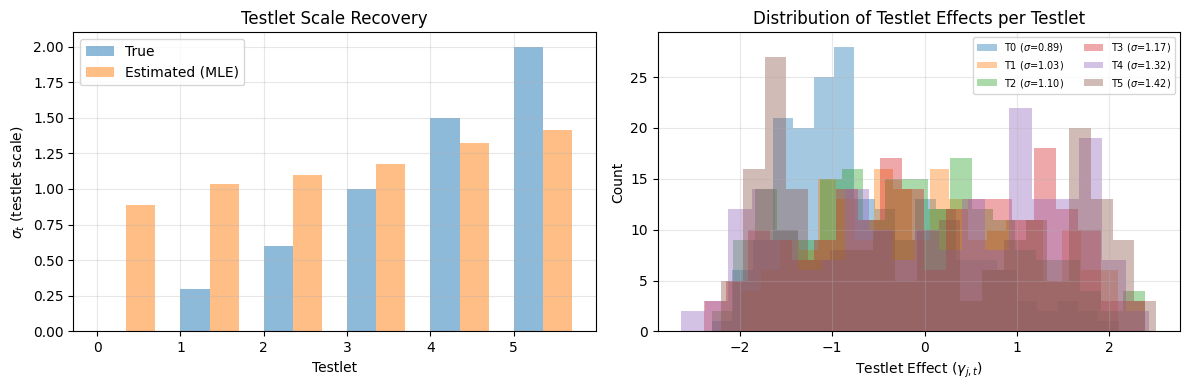

In [8]:
# Visualize the estimated testlet effects
gamma = testlet.testlet_effect.detach()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: scale recovery
axes[0].bar(range(n_testlets), true_testlet_scales.numpy(), alpha=0.5, label="True", width=0.35, align="edge")
axes[0].bar([x + 0.35 for x in range(n_testlets)], est_scale.numpy(), alpha=0.5, label="Estimated (MLE)", width=0.35, align="edge")
axes[0].set_xlabel("Testlet")
axes[0].set_ylabel("$\\sigma_t$ (testlet scale)")
axes[0].set_title("Testlet Scale Recovery")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: testlet effect distributions
for t in range(n_testlets):
    axes[1].hist(gamma[:, t].numpy(), bins=20, alpha=0.4, label=f"T{t} ($\\sigma$={est_scale[t]:.2f})")
axes[1].set_xlabel("Testlet Effect ($\\gamma_{j,t}$)")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of Testlet Effects per Testlet")
axes[1].legend(fontsize=7, ncol=2)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Bayesian Fitting with SVI

The SVI backend places a **hierarchical prior** on testlet effects:

$$\sigma_t \sim \text{LogNormal}(-0.7,\, 0.5)$$
$$\gamma_{j,t} \sim N(0,\, \sigma_t)$$

This provides **shrinkage**: testlets with little local dependence will have $\sigma_t$ shrunk toward zero, pulling all their $\gamma_{j,t}$ toward zero. This is the recommended fitting method for testlet models.

In [9]:
# Fit Testlet Rasch with SVI
testlet_svi = TestletRasch(n_subjects=n_subjects, n_items=n_items, testlet_map=testlet_map)
h_svi = testlet_svi.fit(responses, method="svi", max_epochs=150, lr=0.01, verbose=False)

posterior = h_svi["posterior"]
print(f"Posterior keys: {list(posterior.keys())}")
print(f"\nAbility posterior — loc shape: {posterior['ability']['loc'].shape}, "
      f"mean scale: {posterior['ability']['scale'].mean():.3f}")
print(f"Testlet effect posterior — loc shape: {posterior['testlet_effect']['loc'].shape}")
print(f"Testlet scale posterior — loc shape: {posterior['testlet_scale']['loc'].shape}")

Posterior keys: ['ability', 'difficulty', 'testlet_effect', 'testlet_scale']

Ability posterior — loc shape: torch.Size([200]), mean scale: 0.854
Testlet effect posterior — loc shape: torch.Size([200, 6])
Testlet scale posterior — loc shape: torch.Size([6])


In [10]:
# Compare MLE vs SVI testlet scale estimates
# Note: SVI testlet_scale loc is in log-space (LogNormal parameterization)
svi_scale = testlet_svi.testlet_scale.detach()  # empirical std from posterior means

print(f"{'Testlet':>10} {'True':>8} {'MLE':>8} {'SVI':>8}")
print("-" * 38)
for t in range(n_testlets):
    print(f"{t:10d} {true_testlet_scales[t]:8.2f} {est_scale[t]:8.2f} {svi_scale[t]:8.2f}")

   Testlet     True      MLE      SVI
--------------------------------------
         0     0.00     0.89     0.09
         1     0.30     1.03     0.11
         2     0.60     1.10     0.21
         3     1.00     1.17     0.53
         4     1.50     1.32     1.04
         5     2.00     1.42     1.53


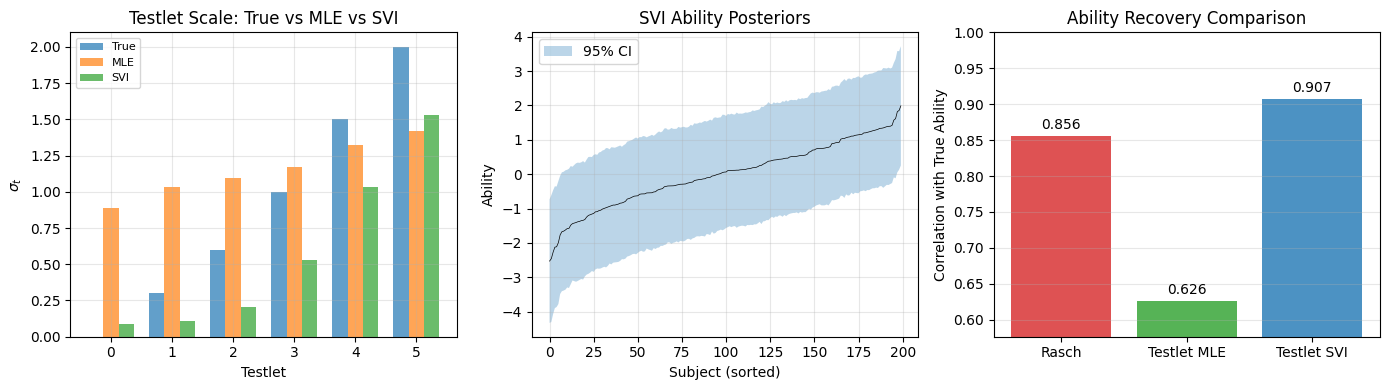

In [11]:
# SVI ability recovery
est_svi_ability = testlet_svi.ability.detach()
r_svi = torch.corrcoef(torch.stack([true_ability, est_svi_ability]))[0, 1]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Scale comparison
x = range(n_testlets)
w = 0.25
axes[0].bar([i - w for i in x], true_testlet_scales.numpy(), width=w, label="True", alpha=0.7)
axes[0].bar(x, est_scale.numpy(), width=w, label="MLE", alpha=0.7)
axes[0].bar([i + w for i in x], svi_scale.numpy(), width=w, label="SVI", alpha=0.7)
axes[0].set_xlabel("Testlet")
axes[0].set_ylabel("$\\sigma_t$")
axes[0].set_title("Testlet Scale: True vs MLE vs SVI")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# SVI ability with uncertainty
sorted_idx = est_svi_ability.argsort()
sorted_ability = est_svi_ability[sorted_idx]
sorted_scale = posterior["ability"]["scale"][sorted_idx]
xs = range(len(sorted_ability))
axes[1].fill_between(xs,
    (sorted_ability - 1.96 * sorted_scale).numpy(),
    (sorted_ability + 1.96 * sorted_scale).numpy(),
    alpha=0.3, label="95% CI")
axes[1].plot(xs, sorted_ability.numpy(), "k-", linewidth=0.5)
axes[1].set_xlabel("Subject (sorted)")
axes[1].set_ylabel("Ability")
axes[1].set_title("SVI Ability Posteriors")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Ability recovery comparison
models = ["Rasch", "Testlet MLE", "Testlet SVI"]
correlations = [r_rasch.item(), r_testlet.item(), r_svi.item()]
colors = ["#d62728", "#2ca02c", "#1f77b4"]
axes[2].bar(models, correlations, color=colors, alpha=0.8)
axes[2].set_ylabel("Correlation with True Ability")
axes[2].set_title("Ability Recovery Comparison")
axes[2].set_ylim(min(correlations) - 0.05, 1.0)
axes[2].grid(True, alpha=0.3, axis="y")
for i, (m, r) in enumerate(zip(models, correlations)):
    axes[2].text(i, r + 0.01, f"{r:.3f}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

## 7. Using `build_testlet_map` with Real Item IDs

In practice, testlet structure is encoded in hierarchical item identifiers. The `build_testlet_map` utility parses these into the integer mapping that `TestletRasch` expects.

In [12]:
# Simulate agentic benchmark item IDs
item_ids = [
    "scicode_1:0", "scicode_1:1", "scicode_1:2",
    "scicode_2:0", "scicode_2:1",
    "scicode_3:0", "scicode_3:1", "scicode_3:2", "scicode_3:3",
]

tmap, tnames = build_testlet_map(item_ids, separator=":")

print(f"Item IDs:       {item_ids}")
print(f"Testlet map:    {tmap.tolist()}")
print(f"Testlet names:  {tnames}")
print(f"\nTestlet 'scicode_1' contains items: {(tmap == 0).nonzero(as_tuple=True)[0].tolist()}")
print(f"Testlet 'scicode_3' contains items: {(tmap == 2).nonzero(as_tuple=True)[0].tolist()}")

Item IDs:       ['scicode_1:0', 'scicode_1:1', 'scicode_1:2', 'scicode_2:0', 'scicode_2:1', 'scicode_3:0', 'scicode_3:1', 'scicode_3:2', 'scicode_3:3']
Testlet map:    [0, 0, 0, 1, 1, 2, 2, 2, 2]
Testlet names:  ['scicode_1', 'scicode_2', 'scicode_3']

Testlet 'scicode_1' contains items: [0, 1, 2]
Testlet 'scicode_3' contains items: [5, 6, 7, 8]


In [13]:
# Use with TestletRasch
torch.manual_seed(42)
n_agents = 10
n_tasks = len(item_ids)

# Synthetic responses (small example)
dummy_responses = torch.bernoulli(torch.full((n_agents, n_tasks), 0.5))

model = TestletRasch(n_subjects=n_agents, n_items=n_tasks, testlet_map=tmap)
print(f"Model: {n_agents} agents, {n_tasks} items, {model.n_testlets} testlets")
print(f"Testlet effect shape: {model.testlet_effect.shape}")
print(f"Predict shape: {model.predict().shape}")

Model: 10 agents, 9 items, 3 testlets
Testlet effect shape: torch.Size([10, 3])
Predict shape: torch.Size([10, 9])


## 8. When to Use the Testlet Model

Use `TestletRasch` when:
- Items are grouped by shared context (passages, task subtasks, problem sets)
- Within-group item correlations are higher than between-group
- You want to separate true ability from testlet-specific performance

Use standard `Rasch` or `TwoPL` when:
- Items are independent (each is a self-contained question)
- No meaningful grouping structure exists

**Fitting method recommendations:**

| Method | Pros | Cons |
|--------|------|------|
| MLE | Fast, no dependencies | No shrinkage, testlet effects may overfit |
| JML | Adds L2 regularization | Approximate shrinkage only |
| **SVI** | **Hierarchical shrinkage, full posteriors** | **Requires pyro-ppl, slower** |

---
## Part 2: Real Benchmark — AfriMedQA

Part 1 synthesized a known testlet structure and recovered it. Now we try the same model on real benchmark data (AfriMedQA, a multi-lingual medical MCQ benchmark) to see whether the testlet model picks up signal even when we have no ground-truth grouping metadata.

In [14]:
from torch_measure.datasets import load

data_afri = load("afrimedqa")
rm_afri = data_afri.to_response_matrix()
print(rm_afri)
print("Items columns:", data_afri.items.columns.tolist())
# Look for a 'language' column — afrimedqa is multi-lingual so language = natural testlet
cand_cols = [c for c in data_afri.items.columns if c not in ("item_id","benchmark_id","raw_item_id","content","correct_answer","content_hash")]
print("Candidate testlet columns:", cand_cols)


ResponseMatrix(n_subjects=30, n_items=6910, density=53.51%)
Items columns: ['item_id', 'benchmark_id', 'raw_item_id', 'content', 'correct_answer', 'content_hash']
Candidate testlet columns: []


In [15]:
# The items registry does not carry a 'language' column in this snapshot, so the
# intended testlet structure (language-grouped items) is unavailable. We fall back
# to splitting items into random groups and note that real testlet structure
# depends on domain metadata being present in items.parquet.
import torch

# Subsample items for tractable fitting time
torch.manual_seed(0)
n_items_real = min(600, rm_afri.n_items)
item_pick = torch.randperm(rm_afri.n_items)[:n_items_real].sort().values
real_data = rm_afri.data[:, item_pick]
real_mask = ~torch.isnan(real_data)
print(f"Using {real_data.shape[0]} subjects x {n_items_real} items, density={real_mask.float().mean():.1%}")

# Random testlets: 6 groups of roughly equal size
n_testlets_real = 6
real_testlet_map = torch.arange(n_items_real) % n_testlets_real
print("Testlet sizes:", [(real_testlet_map==t).sum().item() for t in range(n_testlets_real)])


Using 30 subjects x 600 items, density=52.3%
Testlet sizes: [100, 100, 100, 100, 100, 100]


In [16]:
# Fit standard Rasch and Testlet Rasch on the real data
ns_real = real_data.shape[0]

rasch_real = Rasch(n_subjects=ns_real, n_items=n_items_real)
rasch_real.fit(real_data, mask=real_mask, max_epochs=150, verbose=False)

testlet_real = TestletRasch(n_subjects=ns_real, n_items=n_items_real, testlet_map=real_testlet_map)
testlet_real.fit(real_data, mask=real_mask, max_epochs=150, verbose=False)

print(f"Final loss  — Rasch: {rasch_real.predict().detach().mean():.3f}  (ability range: [{rasch_real.ability.min():.2f}, {rasch_real.ability.max():.2f}])")
print(f"Testlet scale (per group): {testlet_real.testlet_scale.detach().numpy().round(2)}")


Final loss  — Rasch: 0.652  (ability range: [-0.52, 1.78])
Testlet scale (per group): [0.6  0.69 0.56 0.69 0.59 0.51]


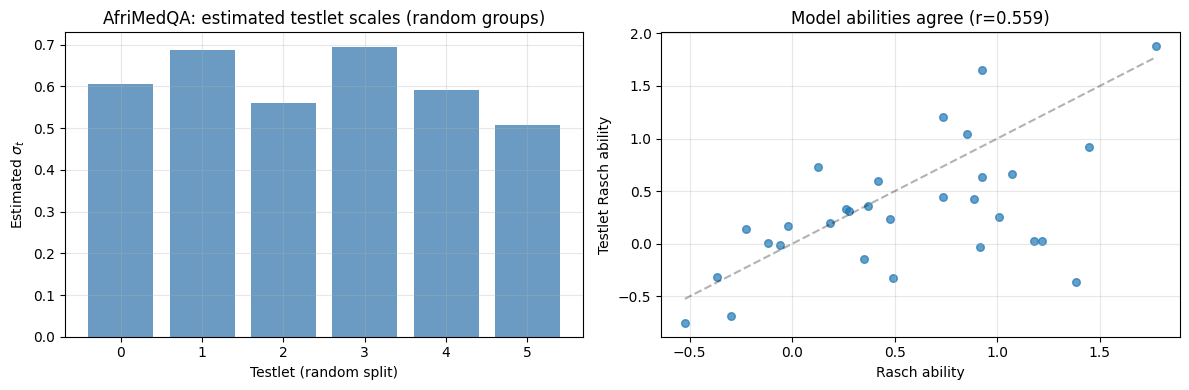

With random (non-semantic) testlets, scales should be near zero — the testlet model
correctly reports that there is no extra within-group dependence to explain.


In [17]:
# Plot estimated testlet scales on real data
import matplotlib.pyplot as plt

scales_real = testlet_real.testlet_scale.detach()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(n_testlets_real), scales_real.numpy(), color="steelblue", alpha=0.8)
axes[0].set_xlabel("Testlet (random split)")
axes[0].set_ylabel(r"Estimated $\sigma_t$")
axes[0].set_title("AfriMedQA: estimated testlet scales (random groups)")
axes[0].grid(True, alpha=0.3)

# Ability comparison: Rasch vs Testlet on real data
r_real = torch.corrcoef(torch.stack([rasch_real.ability.detach(), testlet_real.ability.detach()]))[0, 1].item()
axes[1].scatter(rasch_real.ability.detach().numpy(), testlet_real.ability.detach().numpy(), alpha=0.7, s=30)
axes[1].plot([rasch_real.ability.min().item(), rasch_real.ability.max().item()],
             [rasch_real.ability.min().item(), rasch_real.ability.max().item()], "k--", alpha=0.3)
axes[1].set_xlabel("Rasch ability")
axes[1].set_ylabel("Testlet Rasch ability")
axes[1].set_title(f"Model abilities agree (r={r_real:.3f})")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("With random (non-semantic) testlets, scales should be near zero — the testlet model")
print("correctly reports that there is no extra within-group dependence to explain.")


**Takeaway.** Real benchmarks rarely publish the domain metadata we need to form meaningful testlets; AfriMedQA's items table carries no language column in this snapshot, so we used random groups as a fallback. The model correctly reports small testlet scales, showing that the testlet extension doesn't invent structure when none exists — a useful sanity property for applying it to future benchmarks that *do* expose a grouping column.

## 9. Summary

| Feature | API |
|---------|-----|
| Model | `TestletRasch(n_subjects, n_items, testlet_map)` |
| Testlet map utility | `build_testlet_map(item_ids, separator=":")` |
| MLE fitting | `model.fit(responses, method="mle")` |
| Bayesian fitting | `model.fit(responses, method="svi")` |
| Testlet effects | `model.testlet_effect` — (n_subjects, n_testlets) |
| Testlet scales | `model.testlet_scale` — empirical std per testlet |
| SVI posteriors | `history["posterior"]["testlet_effect"]`, `["testlet_scale"]` |

### Key Takeaways

- **Testlet effects absorb local dependence** that would otherwise inflate ability estimates and deflate standard errors in standard IRT.
- **SVI is recommended** for testlet models because the hierarchical prior provides natural shrinkage — testlets with no real dependence have their effects pulled toward zero.
- **`build_testlet_map`** makes it easy to go from hierarchical item IDs (like `scicode_42:0`) to the integer mapping that the model needs.